# Detecting Marked Nodes with TLNAN
Sergio A. Ortega and Daniel K. Park

In this notebook we show the simulation of an algorithm for detecting the presence of marked nodes on graphs using Szegedy quantum walk and quantum phase estimation.

For reference, see section V. A. of our paper:

**[S. A. Ortega and M. A. Martin-Delgado. SQUWALS: A Szegedy QUantum WALks Simulator. Advanced Quantum Technologies, 7:2400022, 2024.](https://advanced.onlinelibrary.wiley.com/doi/full/10.1002/qute.202400022)**

First we import the libraries that we need, including our simulator library.

In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import tlnan as tl

We create a 2D lattice with networkx with periodic boundary conditions.

In [3]:
N = 1024

gr = nx.scale_free_graph(N,seed=32)
n = int(np.sqrt(N))
N = n**2
gr = nx.grid_2d_graph(n, n, periodic=True)

We obtain a symmetric digraph.

In [4]:
gr = nx.convert_node_labels_to_integers(gr).to_undirected().to_directed()

This graph is sparse, so that we use the sparse framework for simulating the walk. For this, we need to obtain a list with the edges.

In [5]:
edges = list(set(gr.edges))
edges.sort()

We mark the last $M$ nodes removing their outgoing links, and adding loops. Moreover, since all the edges of a node have the same probability, and they connect to $4$ nodes, the weight for them is $1/4$. For marked nodes, they are marked putting the outgoing edges to $0$, and adding a loop with $1$.

In [6]:
M = 10

marked_nodes = np.arange(N-M,N)

non_marked = np.arange(N-M)

In [7]:
edges_weight = []
for edge in edges:
    node = edge[0]
    if node < N-M:
        weighted_edge = [edge[0],edge[1],1/4]
        edges_weight.append(weighted_edge)
    else:
        weighted_edge = [edge[0],edge[1],0]
        edges_weight.append(weighted_edge)
for node in marked_nodes:
    weighted_edge = [int(node),int(node),1]
    edges_weight.append(weighted_edge)  

We use the list of weithed edges to obtain the state space data.

In [8]:
sd = tl.SpaceData(edges_weight)

With the space data and the weighted list we obtain the sparse transition matrix.

In [9]:
transition_matrix = sd.obtain_transition_matrix(edges_weight)

We check that it is normalized.

In [10]:
sd.check_transition_matrix(transition_matrix)

True

We obtain the Szegedy unitary evolution.

In [11]:
R = sd.Reflection(transition_matrix)
S = sd.Swap()

U = S * R * S * R

We create the initial state of the Szegedy register. It is a equal linear combination of the $|\psi_i>$ states corresponding to unmarked nodes.

In [12]:
sz_state = sd.create_initial_state(transition_matrix,nodes=non_marked)

We perform the QPE algorithm on this state with the operator of the graph.

In [13]:
ph_qubits = 6

tensor = tl.qpe.direct_qpe(U, sz_state, ph_qubits)

We measure the phase register and obtain the probabilities.

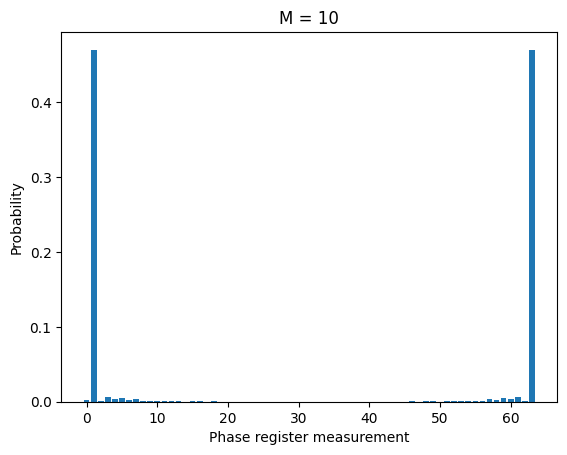

In [14]:
probs = tl.qpe.PhaseMeasurement().operate(tensor)

plt.bar(np.arange(2**ph_qubits),probs)
plt.xlabel('Phase register measurement')
plt.ylabel('Probability')
plt.title(f'M = {M}')
plt.show()

As we can see, it its highly likely to measure a phase different to $0$, so that the graph has marked nodes.

Finally, let us check the results when there are no marked nodes, so $M=0$.

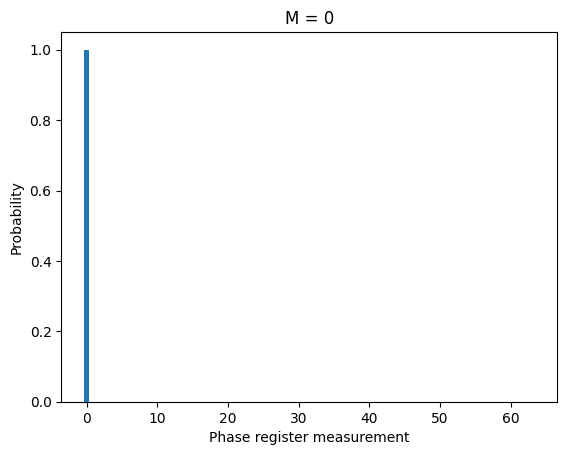

In [15]:
edges_weight = [(a,b,1/4) for a,b in edges] # Withouth marked nodes all edges have probability 1/4.

transition_matrix = sd.obtain_transition_matrix(edges_weight)

R = sd.Reflection(transition_matrix)
S = sd.Swap()
U = S * R * S * R

sz_state = sd.create_initial_state(transition_matrix) # All nodes.

ph_qubits = 6

tensor = tl.qpe.direct_qpe(U, sz_state, ph_qubits)

probs = tl.qpe.PhaseMeasurement().operate(tensor)

plt.bar(np.arange(2**ph_qubits),probs)
plt.xlabel('Phase register measurement')
plt.ylabel('Probability')
plt.title(f'M = {0}')
plt.show()

In this case, the phase $0$ is measured with probability $1$.